# Physics features vs black box: predicting MPEA yield strength

**Question.** Do features from dislocation / solid-solution-strengthening theory
(atomic size misfit, shear-modulus mismatch, VEC) predict the yield strength of
multi-principal-element alloys (MPEAs) better than a black-box model on raw
composition — when the model is tested on **alloy families it has never seen**?

**Data.** Borg et al. (2020), *Scientific Data* 7, 430 —
[CitrineInformatics/MPEA_dataset](https://github.com/CitrineInformatics/MPEA_dataset) (Apache-2.0).
Loaded directly from GitHub at a pinned commit; no data is stored in this repo.

**Outline**
1. Load and clean (room-temperature yield strength, repeated alloys)
2. Features: composition fractions (black box) vs physics features
3. Random Forest, two feature sets, two validation schemes (random K-fold vs GroupKFold by alloy family)
4. Results table and chart

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score

SEED_LIST = [0, 1, 2, 3, 4]   # repeat each CV scheme with 5 different shuffles
N_FOLDS = 5
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("results"); RES_DIR.mkdir(exist_ok=True)

## 1. Load the data

In [2]:
COMMIT = "d31e2510cccc3fb9e79d43ad62652f64ef8c2c5e"   # pinned for reproducibility
URL = f"https://raw.githubusercontent.com/CitrineInformatics/MPEA_dataset/{COMMIT}/MPEA_dataset.csv"
LOCAL = Path("data/raw/MPEA_dataset.csv")              # optional local copy (not committed)

raw = pd.read_csv(LOCAL if LOCAL.exists() else URL)
print("records:", raw.shape[0], "| unique alloys:", raw["FORMULA"].nunique())

records: 1545 | unique alloys: 630


## 2. Clean

Decisions (each one is a modelling choice, stated explicitly):

- **Target = yield strength at room temperature (15–30 °C).** Strength depends strongly on
  test temperature; restricting to room temperature removes that confound instead of asking
  the model to learn it from few points.
- **Drop alloys containing carbon.** C is an interstitial; the substitutional
  size/modulus-misfit picture does not describe it.
- **Repeated measurements:** the same alloy appears several times (different papers, tension vs
  compression, processing). Records are collapsed to the **median** yield strength per
  *(alloy, test type, processing route)*.
- **Alloy family = the set of elements present**, ignoring proportions. Example: every
  Al<sub>x</sub>CoCrFeNi variant is one family. This is the grouping used for GroupKFold.

In [3]:
YS, T = "PROPERTY: YS (MPa)", "PROPERTY: Test temperature ($^\\circ$C)"
TEST, PROC = "PROPERTY: Type of test", "PROPERTY: Processing method"

def parse(formula):
    # 'Al0.5 Co1 Cr1' -> {'Al': 0.143, 'Co': 0.286, ...} (atomic fractions)
    parts = re.findall(r"([A-Z][a-z]?)([\d.]+)", formula)
    amt = {el: float(x) for el, x in parts}
    tot = sum(amt.values())
    return {el: x / tot for el, x in amt.items()}

d = raw[raw[YS].notna() & raw[T].between(15, 30)].copy()
print("room-temperature YS records:", len(d))
d["comp"] = d["FORMULA"].apply(parse)
d = d[~d["comp"].apply(lambda c: "C" in c)]
print("after dropping C-containing alloys:", len(d))

# canonical formula string (sorted, rounded fractions) so identical alloys match
d["alloy"] = d["comp"].apply(lambda c: " ".join(f"{k}{v:.3f}" for k, v in sorted(c.items())))
d["family"] = d["comp"].apply(lambda c: "-".join(sorted(c)))
d["test"] = d[TEST].fillna("C")
d["proc"] = d[PROC].fillna("UNKNOWN")

df = (d.groupby(["alloy", "test", "proc"], as_index=False)
        .agg(ys=(YS, "median"), family=("family", "first"), comp=("comp", "first"), n_raw=(YS, "size")))
print(f"modelling rows: {len(df)} | unique alloys: {df.alloy.nunique()} | families: {df.family.nunique()}")
df.family.value_counts().head(8)

room-temperature YS records: 722
after dropping C-containing alloys: 699
modelling rows: 444 | unique alloys: 375 | families: 143


family
Al-Co-Cr-Fe-Ni       26
Mo-Nb-Ti-V-Zr        23
Al-Co-Cr-Fe-Ni-Ti    13
Al-Cr-Fe-Mn-Ni       12
Al-Cr-Fe-Ni          12
Co-Cr-Fe-Mo-Ni       12
Al-Co-Cr-Fe-Mn-Ni    10
Al-Co-Cr-Cu-Fe-Ni    10
Name: count, dtype: int64

## 3. Features

**Black box:** atomic fraction of every element (one column per element).

**Physics features** (from composition only, with the elemental table below):

| feature | definition | why |
|---|---|---|
| δ (size misfit) | $\sqrt{\sum_i c_i (1 - r_i/\bar r)^2}$ | lattice distortion that pins dislocations |
| δG (modulus mismatch) | $\sqrt{\sum_i c_i (1 - G_i/\bar G)^2}$ | local variation in dislocation line energy |
| VEC | $\sum_i c_i\,\mathrm{VEC}_i$ | electronic proxy for BCC vs FCC stability |
| $\bar G$ | $\sum_i c_i G_i$ | strength scale in solid-solution theory |
| $\bar G\,\delta^{4/3}$ | product | Varvenne–Curtin-type scaling of solid-solution strengthening |

**Shared context (both models):** test type (compression / tension) and processing route.
The two models differ *only* in how composition is represented.

Elemental values: 12-fold metallic radii (Å), room-temperature polycrystalline shear modulus (GPa),
and valence electron count. These are approximate handbook values compiled for this
notebook; replacing them with a single cited table is listed under next steps.

In [4]:
#            r (Å)   G (GPa)  VEC
ELEM = {
    "Ag": (1.445,  30.0, 11), "Al": (1.432,  26.0,  3), "Ca": (1.976,   7.4,  2),
    "Co": (1.251,  75.0,  9), "Cr": (1.249, 115.0,  6), "Cu": (1.278,  48.0, 11),
    "Fe": (1.241,  82.0,  8), "Hf": (1.578,  30.0,  4), "Li": (1.519,   4.2,  1),
    "Mg": (1.601,  17.0,  2), "Mn": (1.264,  80.0,  7), "Mo": (1.363, 120.0,  6),
    "Nb": (1.429,  38.0,  5), "Ni": (1.246,  76.0, 10), "Pd": (1.376,  44.0, 10),
    "Re": (1.375, 178.0,  7), "Sc": (1.641,  29.0,  3), "Si": (1.153,  66.0,  4),
    "Sn": (1.623,  18.0,  4), "Ta": (1.430,  69.0,  5), "Ti": (1.462,  44.0,  4),
    "V":  (1.316,  47.0,  5), "W":  (1.367, 161.0,  6), "Y":  (1.802,  26.0,  3),
    "Zn": (1.335,  43.0, 12), "Zr": (1.603,  33.0,  4),
}
missing = {el for c in df.comp for el in c} - set(ELEM)
assert not missing, f"no elemental data for {missing}"

def physics(c):
    els, x = list(c), np.array(list(c.values()))
    r, G, v = (np.array([ELEM[e][k] for e in els]) for k in range(3))
    rbar, Gbar = x @ r, x @ G
    delta = np.sqrt(x @ (1 - r / rbar) ** 2)
    dG = np.sqrt(x @ (1 - G / Gbar) ** 2)
    return {"delta": delta, "delta_G": dG, "VEC": x @ v, "G_mean": Gbar, "G_delta43": Gbar * delta ** (4 / 3)}

P = pd.DataFrame(df.comp.apply(physics).tolist(), index=df.index)
elements = sorted(ELEM)
X_comp = pd.DataFrame([[c.get(e, 0.0) for e in elements] for c in df.comp], columns=elements, index=df.index)
ctx = pd.get_dummies(df[["test", "proc"]], dtype=float)

FEATURES = {
    "Black box (composition)": pd.concat([X_comp, ctx], axis=1),
    "Physics features":        pd.concat([P, ctx], axis=1),
}
y, groups = df.ys.values, df.family.values
for k, X in FEATURES.items():
    print(f"{k}: {X.shape[1]} columns")
P.describe().round(3)

Black box (composition): 34 columns
Physics features: 13 columns


,delta,delta_G,VEC,G_mean,G_delta43
count,444.000,444.000,444.000,444.000,444.000
mean,0.047,0.350,6.345,66.573,1.094
std,0.022,0.151,1.712,18.229,0.598
min,0.001,0.028,1.770,13.549,0.015
25%,0.035,0.231,4.608,50.868,0.644
50%,0.050,0.336,6.872,71.990,1.070
75%,0.061,0.462,7.880,80.200,1.559
max,0.110,0.912,9.600,116.571,3.494


## 4. Validation: random split vs split by alloy family

- **Random 5-fold:** rows are shuffled. Close relatives of a test alloy (same family, slightly
  different ratio, or the same alloy in another processing state) usually sit in the training set.
- **GroupKFold by family (5 folds):** whole families are held out. This is the practical question:
  *will the model help with a new alloy system?*

Each scheme is repeated with 5 shuffles. Same learner everywhere: Random Forest, 500 trees,
default settings otherwise. A **mean-predictor** (predicts the training-set average) is included
to show what "no skill" looks like.

In [5]:
def rf(seed):
    return RandomForestRegressor(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=seed)

def splits(scheme, seed):
    if scheme == "Random split":
        return KFold(N_FOLDS, shuffle=True, random_state=seed).split(y)
    return GroupKFold(N_FOLDS, shuffle=True, random_state=seed).split(y, groups=groups)

rows = []
for scheme in ["Random split", "Split by alloy family"]:
    for seed in SEED_LIST:
        folds = list(splits(scheme, seed))
        for model, X in [("Mean predictor", None), *FEATURES.items()]:
            pred = np.empty_like(y)
            for tr, te in folds:
                if X is None:
                    pred[te] = y[tr].mean()
                else:
                    pred[te] = rf(seed).fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
            rows.append(dict(scheme=scheme, model=model, seed=seed,
                             MAE=mean_absolute_error(y, pred), R2=r2_score(y, pred)))
runs = pd.DataFrame(rows)

## 5. Results

In [6]:
order = ["Mean predictor", "Black box (composition)", "Physics features"]
table = (runs.groupby(["scheme", "model"])
             .agg(MAE_mean=("MAE", "mean"), MAE_sd=("MAE", "std"), R2_mean=("R2", "mean"), R2_sd=("R2", "std"))
             .reindex(pd.MultiIndex.from_product([["Random split", "Split by alloy family"], order]))
             .round({"MAE_mean": 0, "MAE_sd": 0, "R2_mean": 2, "R2_sd": 2}))
table.to_csv(RES_DIR / "results_table.csv")
table

MAE_mean  MAE_sd  R2_mean  R2_sd
Random split          Mean predictor              489.0     1.0    -0.01   0.00
                      Black box (composition)     230.0     5.0     0.71   0.01
                      Physics features            251.0     2.0     0.64   0.01
Split by alloy family Mean predictor              495.0     3.0    -0.03   0.02
                      Black box (composition)     301.0    13.0     0.50   0.03
                      Physics features            309.0    10.0     0.50   0.03

In [7]:
# how much does the random split flatter each model?
m = runs.groupby(["scheme", "model"]).MAE.mean().unstack(0)
m["MAE increase on new families"] = (m["Split by alloy family"] / m["Random split"] - 1).map("{:+.0%}".format)
m.loc[order[1:]].round(0)

scheme,Random split,Split by alloy family,MAE increase on new families
model,,,
Black box (composition),230.0,301.0,+31%
Physics features,251.0,309.0,+23%


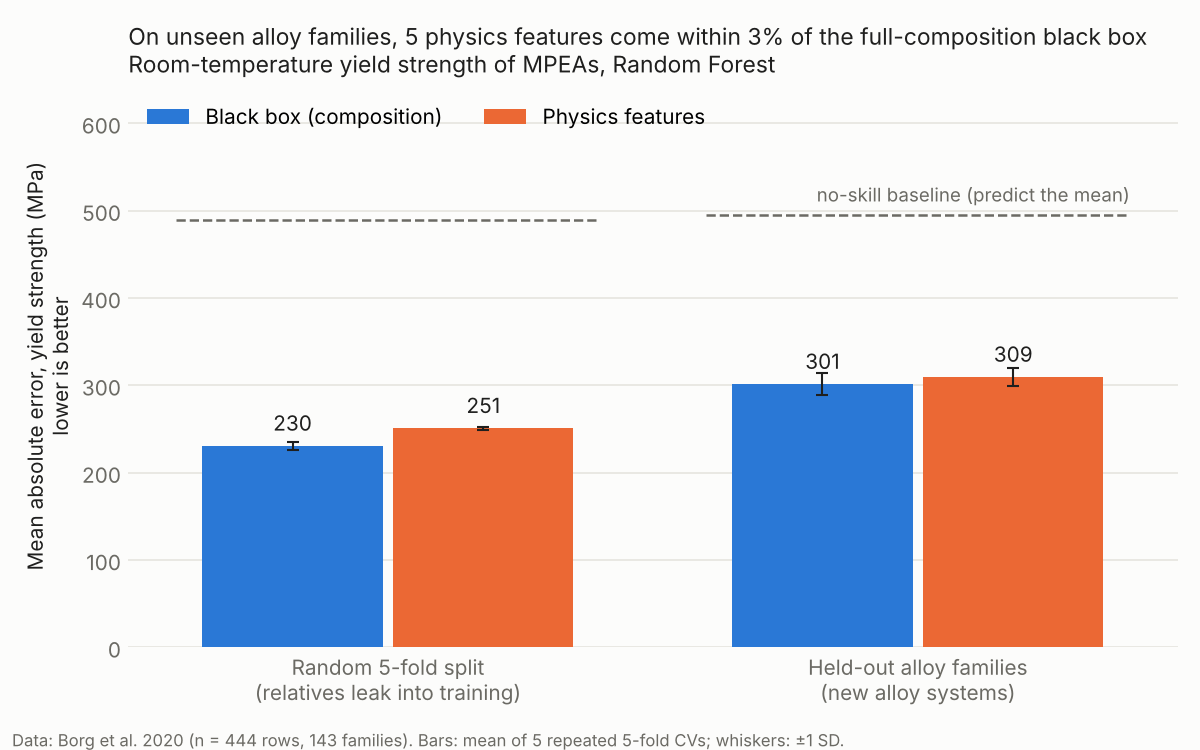

In [8]:
BLUE, ORANGE = "#2a78d6", "#eb6834"          # categorical slots 1-2 (CVD-validated pair)
INK, MUTED, GRID = "#1f1f1e", "#6b6a64", "#e6e5df"
models, colors = order[1:], [BLUE, ORANGE]
schemes = ["Random split", "Split by alloy family"]
xlab = ["Random 5-fold split\n(relatives leak into training)", "Held-out alloy families\n(new alloy systems)"]

agg = runs.groupby(["scheme", "model"]).MAE.agg(["mean", "std"])
base = runs[runs.model == "Mean predictor"].groupby("scheme").MAE.mean()

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
fig.patch.set_facecolor("#fcfcfb"); ax.set_facecolor("#fcfcfb")
w, xs = 0.34, np.arange(2)
for i, (mod, col) in enumerate(zip(models, colors)):
    mu = [agg.loc[(s, mod), "mean"] for s in schemes]
    sd = [agg.loc[(s, mod), "std"] for s in schemes]
    pos = xs + (i - 0.5) * (w + 0.02)
    ax.bar(pos, mu, w, color=col, label=mod, zorder=3)
    ax.errorbar(pos, mu, yerr=sd, fmt="none", ecolor=INK, elinewidth=1, capsize=3, zorder=4)
    for p, v in zip(pos, mu):
        ax.text(p, v + 12, f"{v:.0f}", ha="center", va="bottom", color=INK, fontsize=10)
for x, s in zip(xs, schemes):
    ax.hlines(base[s], x - 0.4, x + 0.4, colors=MUTED, linestyles="--", lw=1.2, zorder=2)
ax.text(xs[1] + 0.4, base[schemes[1]] + 10, "no-skill baseline (predict the mean)", color=MUTED, fontsize=9, ha="right", va="bottom")

ax.set_xticks(xs, xlab, color=INK, fontsize=10)
ax.set_ylabel("Mean absolute error, yield strength (MPa)\nlower is better", color=INK)
ax.set_ylim(0, max(base) * 1.3)
ax.grid(axis="y", color=GRID, zorder=0); ax.tick_params(colors=MUTED, length=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.legend(frameon=False, loc="upper left", ncol=2, fontsize=10)
ax.set_title("On unseen alloy families, 5 physics features come within 3% of the full-composition black box\n"
             "Room-temperature yield strength of MPEAs, Random Forest", loc="left", fontsize=11, color=INK)
fig.text(0.01, 0.005, f"Data: Borg et al. 2020 (n = {len(df)} rows, {df.family.nunique()} families). "
         "Bars: mean of 5 repeated 5-fold CVs; whiskers: ±1 SD.", fontsize=8, color=MUTED)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIG_DIR / "mae_random_vs_family.png", facecolor=fig.get_facecolor())
plt.show()

In [9]:
# which physics features does the model lean on? (impurity importance, family-split model fit on all data)
imp = pd.Series(rf(0).fit(FEATURES["Physics features"], y).feature_importances_,
                index=FEATURES["Physics features"].columns).sort_values(ascending=False)
imp.head(8).round(3)

VEC            0.425
G_delta43      0.164
G_mean         0.151
delta_G        0.089
delta          0.075
test_T         0.031
test_C         0.027
proc_POWDER    0.018
dtype: float64

In [10]:
# paired comparison: same folds, same seed -> physics MAE minus black-box MAE (negative = physics better)
w = runs[runs.model != "Mean predictor"].pivot_table(index=["scheme", "seed"], columns="model", values="MAE")
diff = (w["Physics features"] - w["Black box (composition)"]).groupby("scheme").agg(["mean", "std", "min", "max"])
diff.round(1)

,mean,std,min,max
scheme,,,,
Random split,20.2,3.2,17.4,25.0
Split by alloy family,8.2,13.0,-12.7,19.5


## 6. Answer

See the README for the written answer. Numbers above are the source of truth.